# Tarea 5 — Optimización
**Carlos Andres Tovar · 202311530**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Ejercicio 1: Problema del Viajero (TSP) — Vecino más cercano + 2-opt

### 1. Generación de ciudades

In [ ]:
np.random.seed(42)

n = 10
cities = np.random.uniform(0, 20, size=(n, 2))

### 2. Funciones auxiliares

In [ ]:
def dist_matrix(cities):
    """Construye la matriz de distancias euclidianas entre ciudades."""
    n = len(cities)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.sqrt((cities[i, 0] - cities[j, 0])**2 +
                              (cities[i, 1] - cities[j, 1])**2)
    return D


def tour_distance(tour, D):
    """Calcula la distancia total de un tour cerrado."""
    total = sum(D[tour[k], tour[k + 1]] for k in range(len(tour) - 1))
    total += D[tour[-1], tour[0]]   # regreso al inicio
    return total


D = dist_matrix(cities)

### 3. Fase 1 — Heurística del vecino más cercano

In [ ]:
def nearest_neighbor(D, start=0):
    """Construye un tour greedy partiendo de `start`."""
    n = len(D)
    visited = [False] * n
    tour = [start]
    visited[start] = True

    for _ in range(n - 1):
        current = tour[-1]
        best_next, best_dist = None, np.inf
        for j in range(n):
            if not visited[j] and D[current, j] < best_dist:
                best_dist = D[current, j]
                best_next = j
        tour.append(best_next)
        visited[best_next] = True

    return tour

### 4. Fase 2 — Mejora local con 2-opt

In [ ]:
def two_opt(tour, D):
    """
    Aplica el algoritmo 2-opt hasta convergencia.
    Devuelve el tour mejorado y el historial de distancias por iteración.
    """
    n = len(tour)
    mejora = True
    historial = [tour_distance(tour, D)]

    while mejora:
        mejora = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                a, b = tour[i],     tour[i + 1]
                c, d = tour[j],     tour[(j + 1) % n]

                if D[a, b] + D[c, d] - (D[a, c] + D[b, d]) > 1e-10:
                    tour[i + 1:j + 1] = tour[i + 1:j + 1][::-1]
                    mejora = True
                    historial.append(tour_distance(tour, D))

    return tour, historial

### 5. Ejecución

In [ ]:
start_city   = np.random.randint(n)
tour_inicial = nearest_neighbor(D, start=start_city)
dist_inicial = tour_distance(tour_inicial, D)

tour_final, historial = two_opt(tour_inicial.copy(), D)
dist_final = tour_distance(tour_final, D)

print(f"Ciudad de inicio   : {start_city}")
print(f"Tour inicial (NN)  : {tour_inicial}")
print(f"Distancia inicial  : {dist_inicial:.4f}")
print(f"Tour final (2-opt) : {tour_final}")
print(f"Distancia final    : {dist_final:.4f}")
print(f"Mejora             : {dist_inicial - dist_final:.4f}  "
      f"({100 * (dist_inicial - dist_final) / dist_inicial:.1f} %)")
print(f"Iteraciones 2-opt  : {len(historial) - 1}")

### 6. Visualización

In [ ]:
def plot_tour(ax, cities, tour, title, color='steelblue'):
    tour_closed = tour + [tour[0]]
    xs = cities[tour_closed, 0]
    ys = cities[tour_closed, 1]
    ax.plot(xs, ys, '-o', color=color, markersize=8, linewidth=1.8)
    for i, (x, y) in enumerate(cities):
        ax.annotate(str(i), (x, y), textcoords="offset points",
                    xytext=(6, 6), fontsize=10, fontweight='bold')
    ax.set_xlim(-1, 21)
    ax.set_ylim(-1, 21)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)


# ── Tours: distribución · inicial · final ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax0 = axes[0]
ax0.scatter(cities[:, 0], cities[:, 1], s=100, color='steelblue', zorder=3)
for i, (x, y) in enumerate(cities):
    ax0.annotate(str(i), (x, y), textcoords="offset points",
                 xytext=(6, 6), fontsize=10, fontweight='bold')
ax0.set_xlim(-1, 21)
ax0.set_ylim(-1, 21)
ax0.set_title('Distribución de ciudades', fontsize=12, fontweight='bold')
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.grid(True, alpha=0.3)

plot_tour(axes[1], cities, tour_inicial,
          f'Tour inicial (NN)\nDistancia = {dist_inicial:.2f}', color='tomato')
plot_tour(axes[2], cities, tour_final,
          f'Tour final (2-opt)\nDistancia = {dist_final:.2f}',  color='seagreen')

plt.tight_layout()
plt.show()

# ── Evolución de la distancia ─────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(historial)), historial, 'o-', color='steelblue',
        markersize=6, linewidth=2)
ax.axhline(dist_final, color='seagreen', linestyle='--', linewidth=1.5,
           label=f'Óptimo local = {dist_final:.2f}')
ax.set_xlabel('Iteración 2-opt', fontsize=11)
ax.set_ylabel('Distancia total', fontsize=11)
ax.set_title('Evolución del algoritmo 2-opt', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ejercicio 2: Optimización con Simulated Annealing — Región elíptica

### 1. Función objetivo

In [16]:
np.random.seed(42)

def f(x, y):
    u = x * y
    if abs(u) < 1e-10:
        return 1.0
    return np.sin(u)**2 / u + np.cos(u)**2

### 2. Región factible — Elipse

In [17]:
# Parámetros de la elipse: centro (cx, cy), semiejes a (horizontal), b (vertical)
cx, cy = 5.0, 2.0
a,  b  = 3.0, 2.0


def en_elipse(x, y):
    return ((x - cx)**2 / a**2 + (y - cy)**2 / b**2) <= 1.0


def proyectar_elipse(x, y):
    """Proyecta (x, y) al punto más cercano sobre el borde de la elipse."""
    dx = (x - cx) / a
    dy = (y - cy) / b
    norm = np.sqrt(dx**2 + dy**2)
    if norm == 0:
        return cx + a, cy
    return cx + a * dx / norm, cy + b * dy / norm

### 3. Algoritmo — Simulated Annealing

In [18]:
def simulated_annealing(T0=1.0, alpha=0.995, n_iter=10_000, paso=0.3):
    """
    Minimiza f sobre la elipse mediante Simulated Annealing.
    Parámetros
    ----------
    T0     : temperatura inicial
    alpha  : factor de enfriamiento geométrico  (T_{k+1} = alpha * T_k)
    n_iter : número de iteraciones
    paso   : semiancho del perturbador uniforme
    """
    # Punto inicial aleatorio dentro de la elipse
    while True:
        x = np.random.uniform(cx - a, cx + a)
        y = np.random.uniform(cy - b, cy + b)
        if en_elipse(x, y):
            break

    f_actual          = f(x, y)
    mejor_x, mejor_y  = x, y
    mejor_f           = f_actual
    T                 = T0

    historial_f = [f_actual]
    historial_T = [T]
    historial_x = [x]
    historial_y = [y]

    for _ in range(n_iter):
        xp = x + np.random.uniform(-paso, paso)
        yp = y + np.random.uniform(-paso, paso)

        if not en_elipse(xp, yp):
            xp, yp = proyectar_elipse(xp, yp)

        f_cand = f(xp, yp)
        delta  = f_cand - f_actual

        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            x, y     = xp, yp
            f_actual = f_cand

            if f_actual < mejor_f:
                mejor_x, mejor_y = x, y
                mejor_f          = f_actual

        T = alpha * T

        historial_f.append(f_actual)
        historial_T.append(T)
        historial_x.append(x)
        historial_y.append(y)

    return mejor_x, mejor_y, mejor_f, historial_f, historial_T, historial_x, historial_y

### 4. Ejecución

In [19]:
x_opt, y_opt, f_opt, hist_f, hist_T, hist_x, hist_y = simulated_annealing()

print(f"Punto óptimo : ({x_opt:.6f}, {y_opt:.6f})")
print(f"Valor mínimo : f(x,y) = {f_opt:.6f}")
print(f"En elipse    : {en_elipse(x_opt, y_opt)}")

Punto óptimo : (4.022542, 2.734640)
Valor mínimo : f(x,y) = 0.090927
En elipse    : True


### 5. Visualización

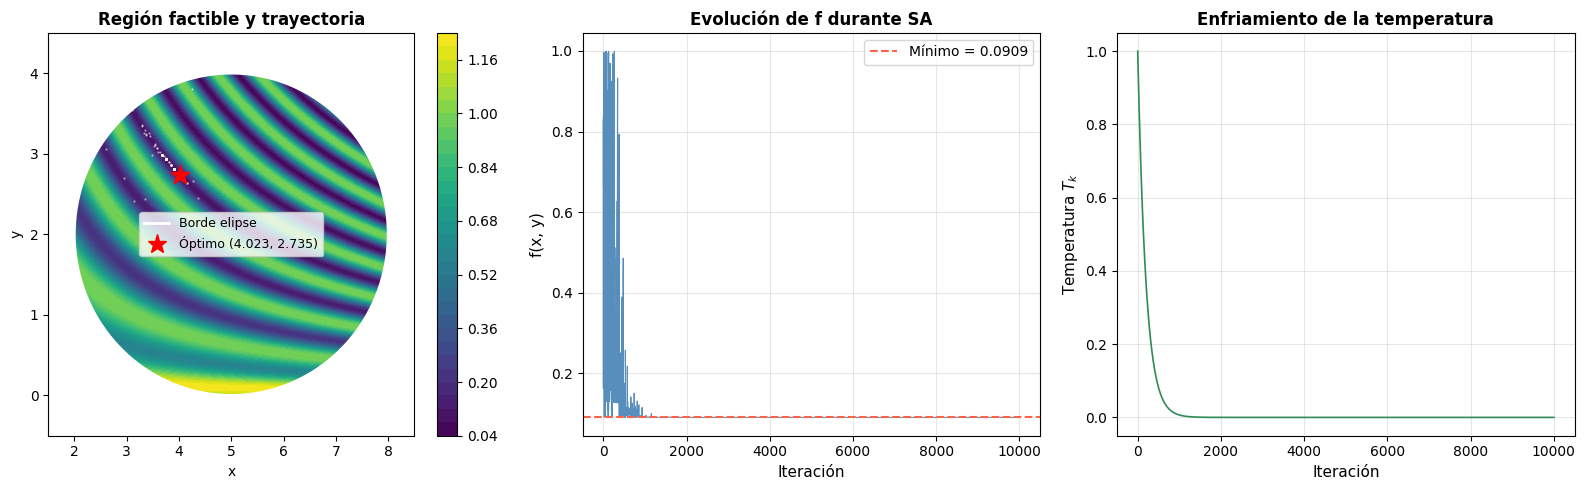

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Gráfica 1: región factible + contornos + trayectoria ─────────────────────
ax1 = axes[0]
xg  = np.linspace(cx - a - 0.5, cx + a + 0.5, 400)
yg  = np.linspace(cy - b - 0.5, cy + b + 0.5, 400)
X, Y = np.meshgrid(xg, yg)
Z    = np.vectorize(f)(X, Y)

mask     = ((X - cx)**2 / a**2 + (Y - cy)**2 / b**2) > 1.0
Z_masked = np.where(mask, np.nan, Z)

cf = ax1.contourf(X, Y, Z_masked, levels=30, cmap='viridis')
plt.colorbar(cf, ax=ax1)

theta = np.linspace(0, 2 * np.pi, 300)
ax1.plot(cx + a * np.cos(theta), cy + b * np.sin(theta),
         'w-', linewidth=2, label='Borde elipse')

step = max(1, len(hist_x) // 200)
ax1.plot(hist_x[::step], hist_y[::step], 'w.', markersize=1.5, alpha=0.4)
ax1.plot(x_opt, y_opt, 'r*', markersize=14,
         label=f'Óptimo ({x_opt:.3f}, {y_opt:.3f})')
ax1.set_title('Región factible y trayectoria', fontsize=12, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend(fontsize=9)

# ── Gráfica 2: evolución de f ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(hist_f, color='steelblue', linewidth=0.8, alpha=0.9)
ax2.axhline(f_opt, color='tomato', linestyle='--', linewidth=1.5,
            label=f'Mínimo = {f_opt:.4f}')
ax2.set_xlabel('Iteración', fontsize=11)
ax2.set_ylabel('f(x, y)', fontsize=11)
ax2.set_title('Evolución de f durante SA', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# ── Gráfica 3: enfriamiento de la temperatura ─────────────────────────────────
ax3 = axes[2]
ax3.plot(hist_T, color='seagreen', linewidth=1.2)
ax3.set_xlabel('Iteración', fontsize=11)
ax3.set_ylabel('Temperatura $T_k$', fontsize=11)
ax3.set_title('Enfriamiento de la temperatura', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ejercicio 3: 8-Reinas — Búsqueda local con perturbaciones

### 1. Función de conflictos

In [ ]:
np.random.seed(42)


def conflictos(sigma):
    """Cuenta pares de reinas en conflicto diagonal."""
    n = len(sigma)
    h = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            if abs(sigma[i] - sigma[j]) == abs(i - j):
                h += 1
    return h

### 2. Algoritmo — Búsqueda local con intercambios

In [ ]:
def busqueda_local(sigma):
    """
    Minimiza h(sigma) mediante best-improvement sobre intercambios de columnas.
    Si no existe movimiento que mejore, aplica una perturbación aleatoria.
    """
    n              = len(sigma)
    historial_h    = [conflictos(sigma)]
    historial_sig  = [sigma.copy()]
    perturbaciones = 0

    while True:
        h_actual = conflictos(sigma)
        if h_actual == 0:
            break

        mejor_delta = 0
        mejor_par   = None

        for i in range(n - 1):
            for j in range(i + 1, n):
                sigma[i], sigma[j] = sigma[j], sigma[i]
                delta = conflictos(sigma) - h_actual
                sigma[i], sigma[j] = sigma[j], sigma[i]   # deshacer

                if delta < mejor_delta:
                    mejor_delta = delta
                    mejor_par   = (i, j)

        if mejor_par is not None:
            i, j = mejor_par
            sigma[i], sigma[j] = sigma[j], sigma[i]
        else:
            i, j = np.random.choice(n, size=2, replace=False)
            sigma[i], sigma[j] = sigma[j], sigma[i]
            perturbaciones += 1

        historial_h.append(conflictos(sigma))
        historial_sig.append(sigma.copy())

    return sigma, historial_h, historial_sig, perturbaciones

### 3. Ejecución

In [ ]:
sigma_inicial = list(np.random.permutation(8) + 1)
sigma_final, hist_h, hist_sig, n_pert = busqueda_local(sigma_inicial.copy())

print(f"Configuración inicial : {sigma_inicial}")
print(f"Conflictos iniciales  : {conflictos(sigma_inicial)}")
print(f"Configuración final   : {sigma_final}")
print(f"Conflictos finales    : {conflictos(sigma_final)}")
print(f"Iteraciones totales   : {len(hist_h) - 1}")
print(f"Perturbaciones        : {n_pert}")

### 4. Visualización

In [ ]:
def dibujar_tablero(ax, sigma, titulo):
    n = 8
    for fila in range(n):
        for col in range(n):
            color = '#f0d9b5' if (fila + col) % 2 == 0 else '#b58863'
            ax.add_patch(patches.Rectangle((col, fila), 1, 1, color=color))

    for col, fila in enumerate(sigma):
        ax.text(col + 0.5, fila - 1 + 0.5, '♛',
                ha='center', va='center', fontsize=18, color='black')

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_yticks(np.arange(n) + 0.5)
    ax.set_xticklabels(range(1, n + 1))
    ax.set_yticklabels(range(1, n + 1))
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.tick_params(length=0)


fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
dibujar_tablero(ax1, sigma_inicial,
                f'Configuración inicial\nh = {conflictos(sigma_inicial)}')

ax2 = fig.add_subplot(1, 3, 2)
dibujar_tablero(ax2, sigma_final,
                f'Configuración final\nh = {conflictos(sigma_final)}')

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(hist_h, color='steelblue', linewidth=1.5)
ax3.axhline(0, color='seagreen', linestyle='--', linewidth=1.5,
            label='h = 0 (solución)')
ax3.set_xlabel('Iteración', fontsize=11)
ax3.set_ylabel('Conflictos h(σ)', fontsize=11)
ax3.set_title('Evolución del algoritmo', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()